<a href="https://colab.research.google.com/github/Giorgosman13/RL_Assignment1/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming Assignment 1 (Stochastic Bandits): Wireless Channel Allocation with Two Feedback Modes**



**Author:** Lampeas Antonios-Panagiotis



**StudentID:** 2022030135

In [8]:
#initialize parameters
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

style.use('ggplot')

K = 5   #number of channels
i = 2   #number of users
T1 = 2000
T2 = 20000
epsilon = 0.6
seed = 35
rewards = []
arms = []
np.random.seed(seed)
horizons = [2000, 20000]

#initialize arms
for j1 in range(K):
    for j2 in range(K):
        if j1 != j2:
            arms.append((j1, j2))

#baseline snr
snr_baseline = np.random.uniform(0.8, 2.0, (i, K))

In [9]:
t_rate = np.log(1 + 10 * snr_baseline)  #expected rate / reward
t_mi = np.array([t_rate[0, j1] + t_rate[1, j2] for j1, j2 in arms])  #expected mi / mean value of reward for each arm
t_mi_star = np.max(t_mi)  #expected mi* (best arm)

#calculating expected rewards
def calc_expected_rewards(arm_idx):
    j1, j2 = arms[arm_idx]

    #calculating expected r1 and r2
    r_1 = np.log(1 + 10 * snr_baseline[0, j1])
    r_2 = np.log(1 + 10 * snr_baseline[1, j2])

    #i dont return the sum of r1 and r2 because i want to keep them separate so i can use the same function for both cases
    return (r_1, r_2)

#calculating actual rewards with noise
def calc_actual_rewards(arm_idx):
    j1, j2 = arms[arm_idx]

    #calculating actual s1 and s2 with noise
    s_1_t = np.random.uniform(snr_baseline[0, j1] - epsilon, snr_baseline[0, j1] + epsilon)
    s_2_t = np.random.uniform(snr_baseline[1, j2] - epsilon, snr_baseline[1, j2] + epsilon)

    #calculating actual rewards r1 and r2 based on actual s1 and s2
    r_1_t = np.log(1 + 10 * s_1_t)
    r_2_t = np.log(1 + 10 * s_2_t)

    #i dont return the sum of r1 and r2 because i want to keep them separate so i can use the same function for both cases
    return (r_1_t, r_2_t)


In [10]:
#ucb algorithm for case a (where we use the sum of r1 and r2 as reward)
def run_ucb_case_a(T):
    #initialization of the variables for ucb
    num_arms = len(arms)
    X_i = np.zeros(num_arms)  #array which counts how many times each arm has been chosen
    r_i = np.zeros(num_arms)  #array which stores the sum of rewards for each arm
    mi_hat = np.zeros(num_arms)  #array which stores the estimated mean reward for each arm
    regret = np.zeros(T)  #array which stores the regret for each epoch
    max_snr = 2 + epsilon
    r_max = 2 * np.log(1 + 10 * max_snr)  #this is the max reward we can get from any arm used for calculating regret
    regret_temp = 0

    #algorithmos UCB
    for t in range(T):
        if t < num_arms:
            #the chosen_arm variable is the base i from the slides
            chosen_arm = t  #we have to choose each arm at least once to initialize the estimates and also beacuse we cant devide by zero when calculating the ucb values
        else:
            ucb_values = mi_hat + r_max * np.sqrt((2 * np.log(t)) / X_i)  #culculating the ucb values (idk if we have to use the rmax beacuse of the normalization regulations)
            chosen_arm = np.argmax(ucb_values)  #choosing the arm with the highest ucb value

        (r_1, r_2) = calc_actual_rewards(chosen_arm)  #calculating the actual rewards for the chosen arm
        r_n = r_1 + r_2  #calculating the total reward for the chosen arm (case a)
        X_i[chosen_arm] += 1  #updating the count of times the arm has been chosen(basically the X_i,n variable from the slides, 0 if we didnt use this arm, 1 if we used this arm)
        r_i[chosen_arm] += r_n  #updating the sum of rewards for the arm
        mi_hat[chosen_arm] = r_i[chosen_arm] / X_i[chosen_arm]  #calculating the estimated mean reward for the arm

        regret_temp += t_mi_star - t_mi[chosen_arm]  #calculating the regret
        regret[t] = regret_temp  #storing the regret

    return regret

In [11]:
#ucb algorithm for case b (where we use r1 and r2 separately)
def run_ucb_case_b(T):
    X_1 = np.zeros(K)  #array which counts how many times each channel has been chosen for user 1
    X_2 = np.zeros(K)  #same for user 2
    r_1 = np.zeros(K)  #array which stores the sum of rewards for each channel for user 1
    r_2 = np.zeros(K)  #same for user 2
    mi_hat_1 = np.zeros(K)  #array which stores the estimated mean reward for each channel for user 1
    mi_hat_2 = np.zeros(K)  #same for user 2
    regret = np.zeros(T)
    regret_t = 0
    max_snr = 2 + epsilon
    r_max =  np.log(1 + 10 * max_snr)  #this is the max reward we can get
    for t in range(T):
        if t < K:
            j1 = t
            j2 = (t + 1) % K #using modulo we are sure that j1 != j2 and that it doesnt go over five
            chosen_arm = arms.index((j1,j2)) #finding the index of the chosen arm in the arms list
        else:
            ucb_values_1 = mi_hat_1 + r_max * np.sqrt((2 * np.log(t)) / X_1)  #calculating the ucb values for user 1(i dont use rmax because of the normalization regulations)
            ucb_values_2 = mi_hat_2 + r_max * np.sqrt((2 * np.log(t)) / X_2)  #calculating the ucb values for user 2

            aggregate_rewards = [ucb_values_1[a[0]] + ucb_values_2[a[1]] for a in arms]  #calculating the aggregate rewards for each arm by summing the ucb values of the channels used by each arm
            chosen_arm = np.argmax(aggregate_rewards)

        reward_1, reward_2 = calc_actual_rewards(chosen_arm)  #calculating the actual rewards for the chosen arm
        j1, j2 = arms[chosen_arm]  #getting the channels used by the chosen arm

        X_1[j1] += 1  #updating the count of times the channel j1 has been chosen for user 1
        X_2[j2] += 1  #same for user 2
        r_1[j1] += reward_1  #updating the sum of rewards for the channel j1 for user 1
        r_2[j2] += reward_2  #same for user 2
        mi_hat_1[j1] = r_1[j1] / X_1[j1]  #updating the estimated mean reward for the channel j1 for user 1
        mi_hat_2[j2] = r_2[j2] / X_2[j2]  #same for user 2

        regret_t += t_mi_star - t_mi[chosen_arm]  #calculating the regret
        regret[t] = regret_t  #storing the regret

    return regret

In [12]:
#calculating the bound for case a
def calc_bound_case_a(T):
    r_max = 2 * np.log(1 + 10 * (2 + epsilon))
    num_arms = len(arms)
    bound = np.zeros(T)

    for t in range(T):
        bound[t] = r_max * np.sqrt(num_arms * t * np.log(t+1))
    return bound

In [13]:
#calculating the bound for case b
def calc_bound_case_b(T):
    r_max = 2 * np.log(1 + 10 * (2 + epsilon))
    bound = np.zeros(T)

    for t in range(T):
        bound[t] = r_max * np.sqrt(2 * K * t * np.log(t+1))
    return bound

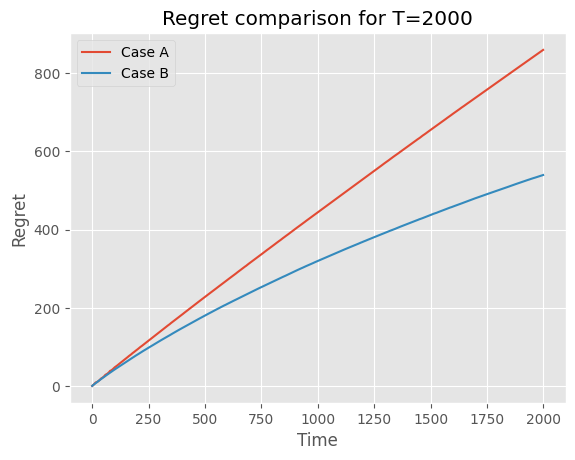

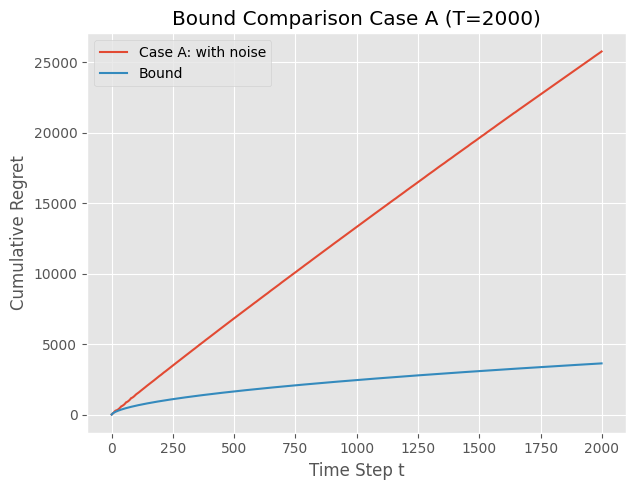

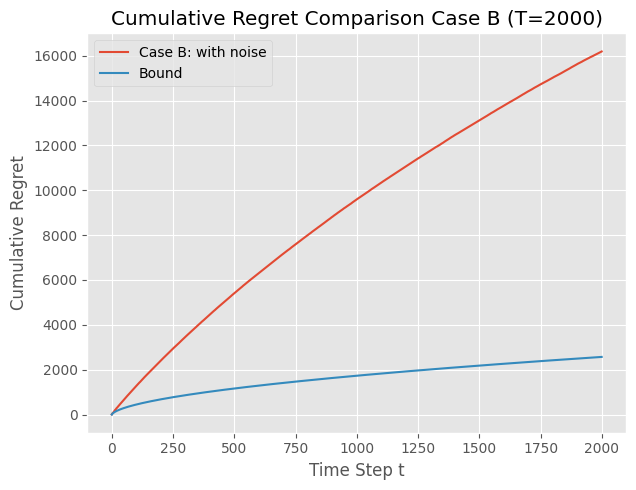

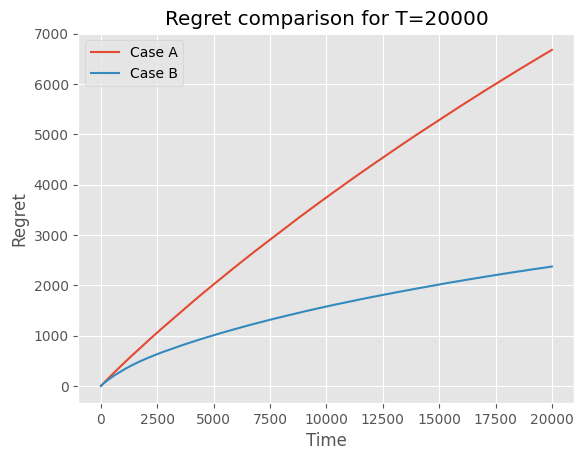

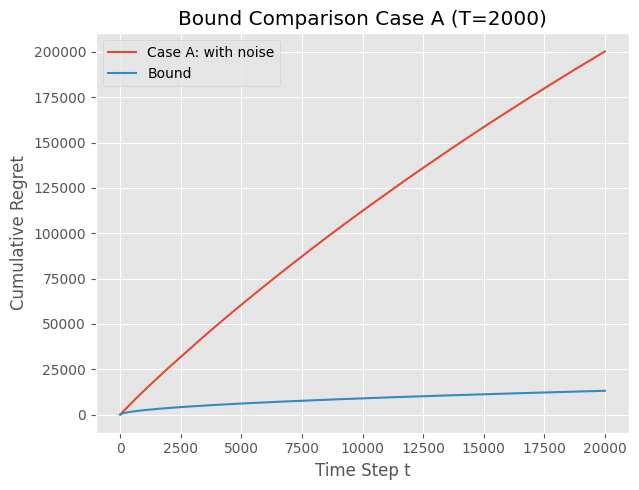

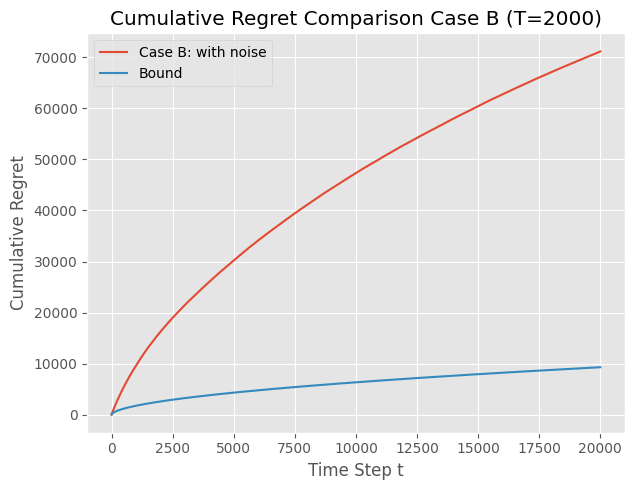

In [14]:
epochs = 30

for T in horizons:
    regret_a = np.zeros(T)
    regret_b = np.zeros(T)

    for e in range(epochs):
        regret_a += run_ucb_case_a(T)
        regret_b += run_ucb_case_b(T)
        therotical_bound_a = calc_bound_case_a(T)
        therotical_bound_b = calc_bound_case_b(T)

    avg_regret_a = regret_a / epochs
    avg_regret_b = regret_b / epochs

    plt.figure()
    plt.plot(avg_regret_a, label='Case A')
    plt.plot(avg_regret_b, label='Case B')
    plt.xlabel('Time')
    plt.ylabel('Regret')
    plt.title(f'Regret comparison for T={T}')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.plot(regret_a, label='Case A: with noise')
    plt.plot(therotical_bound_a, label='Bound')
    plt.title(f'Bound Comparison Case A (T={2000})')
    plt.xlabel('Time Step t')
    plt.ylabel('Cumulative Regret')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.plot(regret_b, label='Case B: with noise')
    plt.plot(therotical_bound_b, label='Bound')
    plt.title(f'Cumulative Regret Comparison Case B (T={2000})')
    plt.xlabel('Time Step t')
    plt.ylabel('Cumulative Regret')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()
